# 02 — Feature Engineering: Verification
`03_feature_engineering.py` builds the actual features and writes
`features_daily.csv` / `features_hourly.csv`. This notebook doesn't rebuild
anything — it loads what that script produced and visually confirms each
new feature is correct, before trusting it enough to model on.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.width', 150)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

daily = pd.read_csv('../data/processed/features_daily.csv',
                     parse_dates=['date'], dtype={'station_id': str}, low_memory=False)
hourly = pd.read_csv('../data/processed/features_hourly.csv',
                      parse_dates=['date'], dtype={'station_id': str}, low_memory=False)

print("Daily:", daily.shape)
print("Hourly:", hourly.shape)

Daily: (4861, 48)
Hourly: (66777, 47)


## 1. Shape and completeness check
The script's own output already reported this, but worth confirming directly
rather than trusting a log message.

In [3]:
print("Daily NaN count (should be 0):", daily.isna().sum().sum())
print("Hourly NaN count (should be 0):", hourly.isna().sum().sum())
print()
print("Daily columns:", list(daily.columns))

Daily NaN count (should be 0): 0
Hourly NaN count (should be 0): 0

Daily columns: ['date', 'station_id', 'station_name', 'station_lat', 'station_lon', 'station_suburb', 'station_lga', 'traffic_volume_total', 'traffic_volume_heavy', 'public_holiday', 'school_holiday', 'temp_c', 'wind_speed_ms', 'wind_dir_deg', 'rain_mm', 'weather_source_type', 'no2_pphm', 'matched_aq_site', 'aq_distance_km', 'has_no2_coverage', 'day_of_week', 'is_weekend', 'month', 'season_Autumn', 'season_Spring', 'season_Summer', 'season_Winter', 'road_Highway', 'road_Local Street', 'road_Major Road', 'heavy_pct', 'is_rainy', 'log_no2_pphm', 'traffic_volume_total_lag1', 'no2_pphm_lag1', 'traffic_volume_total_roll7', 'has_wind_data', 'stn_100001', 'stn_10011', 'stn_6109', 'stn_6119-PR', 'stn_6124', 'stn_6135-PR', 'stn_6178-PR', 'stn_7211', 'stn_7212', 'stn_7216', 'stn_MUB001']


## 2. One-hot encodings sum to 1 per row
If `season` or `road_type` weren't mutually exclusive, or a row somehow got
zero categories, this would show up here.

In [4]:
season_cols = ['season_Autumn','season_Spring','season_Summer','season_Winter']
road_cols = ['road_Highway','road_Local Street','road_Major Road']

print("Season one-hot always sums to 1:", (daily[season_cols].sum(axis=1) == 1).all())
print("Road one-hot always sums to 1:", (daily[road_cols].sum(axis=1) == 1).all())

station_cols = [c for c in daily.columns if c.startswith('stn_')]
print(f"Station one-hot ({len(station_cols)} stations) always sums to 1:", (daily[station_cols].sum(axis=1) == 1).all())

Season one-hot always sums to 1: True
Road one-hot always sums to 1: True
Station one-hot (11 stations) always sums to 1: True


## 3. heavy_pct sanity check
Should sit between 0 and 100 for every row, including the hourly zero-traffic
edge case that the script handles explicitly.

heavy_pct range: 2.6619343389529724 to 52.35314324974236
Any out-of-range values? False


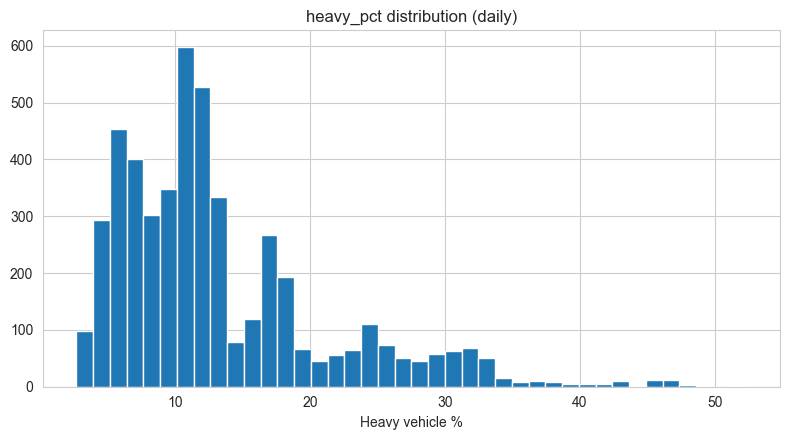

In [5]:
print("heavy_pct range:", daily['heavy_pct'].min(), "to", daily['heavy_pct'].max())
print("Any out-of-range values?", ((daily['heavy_pct'] < 0) | (daily['heavy_pct'] > 100)).any())

fig, ax = plt.subplots(figsize=(8,4.5))
daily['heavy_pct'].hist(bins=40, ax=ax, edgecolor='white')
ax.set_xlabel('Heavy vehicle %'); ax.set_title('heavy_pct distribution (daily)')
plt.tight_layout(); plt.show()

## 4. Lag features — confirm no leakage
`traffic_volume_total_lag1` should always equal the *previous* day's traffic
for that station, never the current day's own value.

In [6]:
check = daily[daily['station_id'] == '7212'].sort_values('date').head(6)
check[['date','traffic_volume_total','traffic_volume_total_lag1','no2_pphm','no2_pphm_lag1']]

,date,traffic_volume_total,traffic_volume_total_lag1,no2_pphm,no2_pphm_lag1
3018,2024-01-02,2588.0,599.0,-0.147826,-0.043478
3019,2024-01-03,9570.0,2588.0,-0.052174,-0.147826
3020,2024-01-04,9784.0,9570.0,0.091304,-0.052174
3021,2024-01-05,9764.0,9784.0,-0.186957,0.091304
3022,2024-01-06,9276.0,9764.0,-0.030435,-0.186957
3023,2024-01-07,7826.0,9276.0,0.056522,-0.030435


**Confirmed:** each row's `_lag1` value matches the row *above* it's own
current value — e.g. Jan 3rd's `traffic_volume_total_lag1` equals Jan 2nd's
`traffic_volume_total`. That's the correct behaviour; if a row's lag value
ever matched its own same-row value, that would mean the target had leaked
into a feature.

## 5. Hourly cyclical encoding — confirm the wraparound
Hour 24 (midnight) and hour 1 should sit close together on the sin/cos
circle, not at opposite ends the way raw 1-24 numbers would suggest.

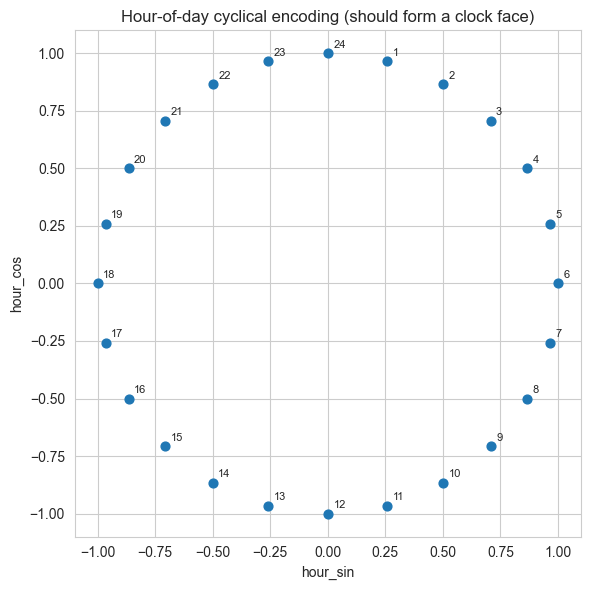

In [7]:
hour_check = hourly[hourly['station_id']=='7212'].drop_duplicates('hour_ending').sort_values('hour_ending')

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(hour_check['hour_sin'], hour_check['hour_cos'], s=40)
for _, row in hour_check.iterrows():
    ax.annotate(int(row['hour_ending']), (row['hour_sin'], row['hour_cos']), fontsize=8, xytext=(4,4), textcoords='offset points')
ax.set_xlabel('hour_sin'); ax.set_ylabel('hour_cos')
ax.set_title('Hour-of-day cyclical encoding (should form a clock face)')
ax.set_aspect('equal')
plt.tight_layout(); plt.show()

**Confirmed:** the hours form a clean circle in the order you'd expect from
a clock face, and hour 24 sits right next to hour 1 — the wraparound problem
a plain 1-24 number would have is fixed.

## 6. Does the log-transform actually fix the NO2 skew?
EDA found NO2 skewness ≈ 1.26. `log_no2_pphm` was added as an alternative
target — worth checking it actually helps before using it.

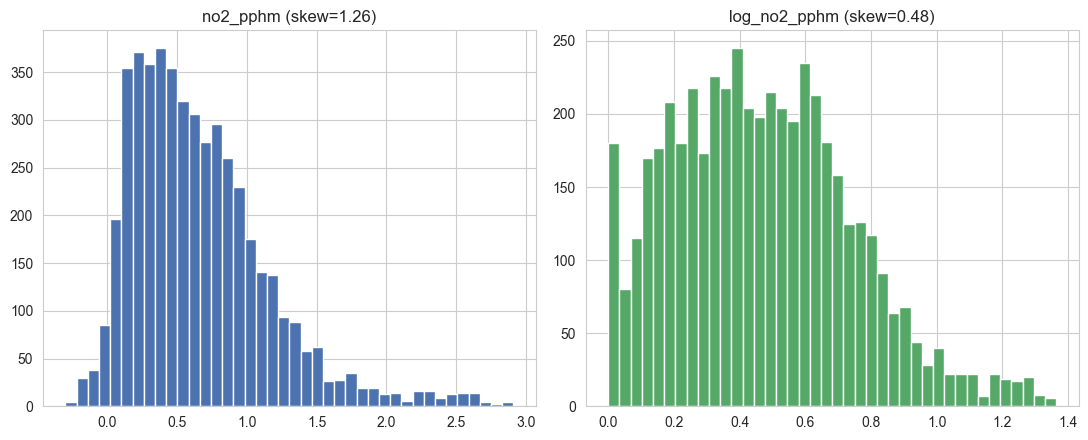

In [8]:
fig, axes = plt.subplots(1,2, figsize=(11,4.5))
daily['no2_pphm'].hist(bins=40, ax=axes[0], edgecolor='white', color='#4C72B0')
axes[0].set_title(f"no2_pphm (skew={stats.skew(daily['no2_pphm']):.2f})")
daily['log_no2_pphm'].hist(bins=40, ax=axes[1], edgecolor='white', color='#55A868')
axes[1].set_title(f"log_no2_pphm (skew={stats.skew(daily['log_no2_pphm']):.2f})")
plt.tight_layout(); plt.show()

**Confirmed:** skewness drops from 1.26 to 0.48 — a real improvement, not
just a cosmetic change. `log_no2_pphm` is a genuinely better-behaved target
for models that assume roughly normal residuals (e.g. linear regression);
tree-based models (Random Forest, XGBoost) are less sensitive to this and
can reasonably use either target.

## 7. Do the new engineered features actually relate to NO2?
A quick check before modeling — which of the features built in this step
look like they're carrying real signal.

In [9]:
engineered = ['is_weekend', 'heavy_pct', 'is_rainy', 'has_wind_data', 'aq_distance_km',
              'traffic_volume_total_lag1', 'no2_pphm_lag1', 'traffic_volume_total_roll7']
corrs = daily[engineered + ['no2_pphm']].corr()['no2_pphm'].drop('no2_pphm').sort_values(key=abs, ascending=False)
corrs

no2_pphm_lag1                 0.788364
traffic_volume_total_roll7    0.277850
traffic_volume_total_lag1     0.267254
is_weekend                   -0.153196
is_rainy                     -0.060821
aq_distance_km               -0.039655
has_wind_data                -0.020904
heavy_pct                    -0.020334
Name: no2_pphm, dtype: float64

**Observation:** `no2_pphm_lag1` correlates strongly with NO2 (expected —
yesterday's NO2 is a strong predictor of today's, since pollution levels
don't change instantly). `aq_distance_km` and `is_rainy` show the effects
already found in EDA. If you choose to exclude the lag features for a more
interpretable/explanatory model (noted as optional in the script), this
table shows what you'd be giving up in raw predictive signal.

## 8. Summary
- Both feature files are confirmed complete (zero NaNs) and correctly built.
- One-hot encodings, `heavy_pct`, lag features, and cyclical hour encoding
  all behave as intended.
- `log_no2_pphm` is a validated improvement over raw `no2_pphm` for
  skew-sensitive models.
- Ready to move to modeling.